In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

sns.set_theme(style='white')

In [2]:
data_home   = 'parsed_data'
table_dir   = 'derived_tables'
output_dir  = 'models'

OHCO  = ['country_id', 'article_id', 'section_id', 'subsection_id', 'sent_id', 'token_id']
SENTS = OHCO[:5]  

emo_cols = 'anger anticipation disgust fear joy sadness surprise trust sentiment'.split()

## Load Data

In [3]:
# Token table
TOKENS = pd.read_csv(f'{data_home}/const_TOKEN.csv').set_index(OHCO).sort_index()
print('TOKENS:', TOKENS.shape)
TOKENS.head()

TOKENS: (4263565, 5)


token_str  \
country_id       article_id section_id subsection_id sent_id token_id                
Afghanistan_2004 0          0          0             0       0         Afghanistan   
                                                             1                2004   
                                                     1       0            Preamble   
                                                     2       0               Share   
                                                     3       0                  In   

                                                                          term_str  \
country_id       article_id section_id subsection_id sent_id token_id                
Afghanistan_2004 0          0          0             0       0         afghanistan   
                                                             1                2004   
                                                     1       0            preamble   
                                                     2       0               share   
                                                     3       0                  in   

                                                                        pos  \
country_id       article_id section_id subsection_id sent_id token_id         
Afghanistan_2004 0          0          0             0       0          ADJ   
                                                             1          NUM   
                                                     1       0          ADJ   
                                                     2       0         NOUN   
                                                     3       0          ADP   

                                                                      pos_group  \
country_id       article_id section_id subsection_id sent_id token_id             
Afghanistan_2004 0          0          0             0       0              ADJ   
                                                             1              NUM   
                                                     1       0              ADJ   
                                                     2       0             NOUN   
                                                     3       0              ADP   

                                                                       is_header  
country_id       article_id section_id subsection_id sent_id token_id             
Afghanistan_2004 0          0          0             0       0             False  
                                                             1             False  
                                                     1       0             False  
                                                     2       0             False  
                                                     3       0             False

In [5]:
salex_file = 'lexicons/salex_nrc.csv' 
SALEX = pd.read_csv(salex_file).set_index('term_str')
SALEX.columns = [col.replace('nrc_', '') for col in SALEX.columns]
print('SALEX:', SALEX.shape)
SALEX.head()

SALEX: (3688, 11)


,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1


## Apply NRC Lexicon

In [6]:
TOKENS_SA = TOKENS.join(SALEX, on='term_str', how='left')
print(f'Tokens with sentiment score: {TOKENS_SA["sentiment"].notna().sum():,}')
print(f'Coverage: {TOKENS_SA["sentiment"].notna().mean():.1%}')
TOKENS_SA.head()

Tokens with sentiment score: 356,950
Coverage: 8.4%


token_str  \
country_id       article_id section_id subsection_id sent_id token_id                
Afghanistan_2004 0          0          0             0       0         Afghanistan   
                                                             1                2004   
                                                     1       0            Preamble   
                                                     2       0               Share   
                                                     3       0                  In   

                                                                          term_str  \
country_id       article_id section_id subsection_id sent_id token_id                
Afghanistan_2004 0          0          0             0       0         afghanistan   
                                                             1                2004   
                                                     1       0            preamble   
                                                     2       0               share   
                                                     3       0                  in   

                                                                        pos  \
country_id       article_id section_id subsection_id sent_id token_id         
Afghanistan_2004 0          0          0             0       0          ADJ   
                                                             1          NUM   
                                                     1       0          ADJ   
                                                     2       0         NOUN   
                                                     3       0          ADP   

                                                                      pos_group  \
country_id       article_id section_id subsection_id sent_id token_id             
Afghanistan_2004 0          0          0             0       0              ADJ   
                                                             1              NUM   
                                                     1       0              ADJ   
                                                     2       0             NOUN   
                                                     3       0              ADP   

                                                                       is_header  \
country_id       article_id section_id subsection_id sent_id token_id              
Afghanistan_2004 0          0          0             0       0             False   
                                                             1             False   
                                                     1       0             False   
                                                     2       0             False   
                                                     3       0             False   

                                                                       anger  \
country_id       article_id section_id subsection_id sent_id token_id          
Afghanistan_2004 0          0          0             0       0           NaN   
                                                             1           NaN   
                                                     1       0           NaN   
                                                     2       0           0.0   
                                                     3       0           NaN   

                                                                       anticipation  \
country_id       article_id section_id subsection_id sent_id token_id                 
Afghanistan_2004 0          0          0             0       0                  NaN   
                                                             1                  NaN   
                                                     1       0                  NaN   
                                                     2       0                  1.0   
                                                     3     

## Compare Countries

Mean sentiment scores per country across all emotion dimensions.

In [7]:
COUNTRY_SA = TOKENS_SA.fillna(0).groupby('country_id')[emo_cols].mean()
COUNTRY_SA.head()

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
country_id,,,,,,,,,
Afghanistan_2004,0.019337,0.040484,0.005239,0.026958,0.032959,0.012098,0.008097,0.065536,0.048485
Albania_2008,0.016689,0.040900,0.005444,0.024712,0.028365,0.010529,0.006876,0.067330,0.052575
Algeria_2008,0.010227,0.046858,0.004742,0.018687,0.033656,0.010506,0.008832,0.076794,0.065173
Andorra_1993,0.010122,0.043899,0.006369,0.021381,0.030479,0.008757,0.008416,0.075970,0.064369
Angola_2010,0.016056,0.032831,0.005566,0.021206,0.024462,0.009694,0.005566,0.058694,0.049720


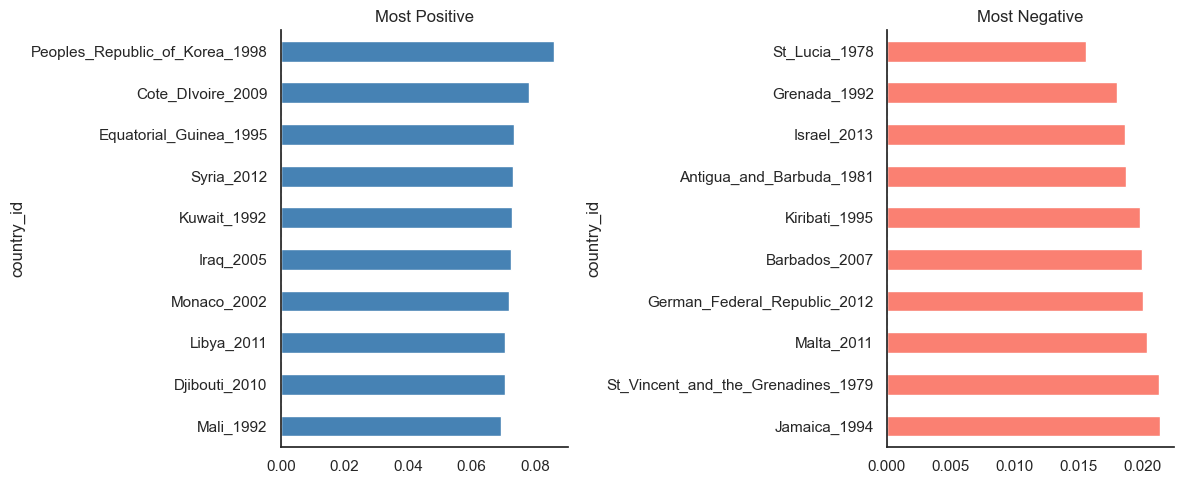

In [8]:
top_pos = COUNTRY_SA['sentiment'].nlargest(10)
top_neg = COUNTRY_SA['sentiment'].nsmallest(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_pos.sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Most Positive')
top_neg.sort_values(ascending=False).plot.barh(ax=axes[1], color='salmon')
axes[1].set_title('Most Negative')
for ax in axes:
    ax.axvline(0, c='lightgray', ls='--')
sns.despine()
plt.tight_layout()
plt.show()

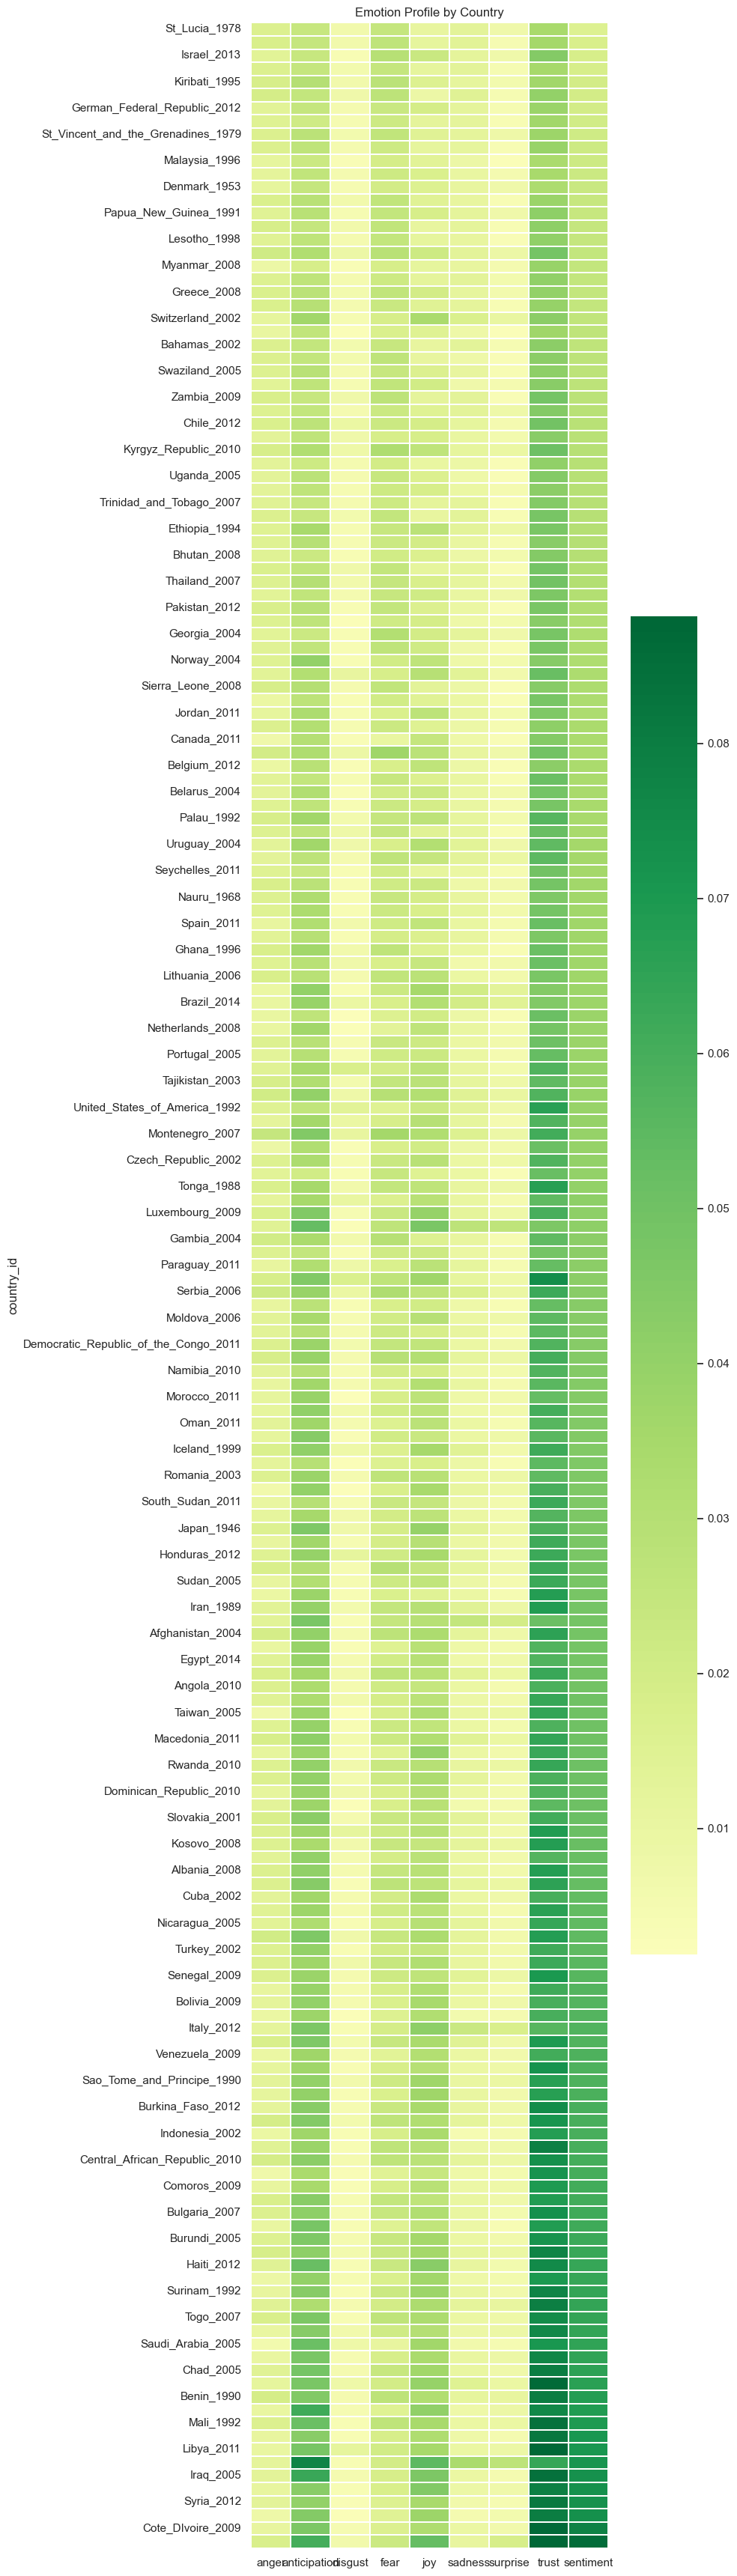

In [9]:
fig, ax = plt.subplots(figsize=(10, max(6, len(COUNTRY_SA) * 0.18)))
sns.heatmap(
    COUNTRY_SA.sort_values('sentiment'),
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.3, linecolor='white'
)
ax.set_title('Emotion Profile by Country')
plt.tight_layout()
plt.show()

## Sentiment at Sentence Level

In [10]:
SENT_SA = TOKENS_SA.groupby(SENTS)[emo_cols].mean()
SENT_SA['sent_str'] = (
    TOKENS_SA
    .groupby(SENTS)[['term_str']]
    .apply(lambda x: ' '.join(x.term_str.dropna().astype(str)))
)
print('SENT_SA:', SENT_SA.shape)
SENT_SA.head()

SENT_SA: (309287, 10)


anger  \
country_id       article_id section_id subsection_id sent_id          
Afghanistan_2004 0          0          0             0          NaN   
                                                     1          NaN   
                                                     2          0.0   
                                                     3          NaN   
                                                     4          0.0   

                                                              anticipation  \
country_id       article_id section_id subsection_id sent_id                 
Afghanistan_2004 0          0          0             0                 NaN   
                                                     1                 NaN   
                                                     2            1.000000   
                                                     3                 NaN   
                                                     4            0.333333   

                                                              disgust  fear  \
country_id       article_id section_id subsection_id sent_id                  
Afghanistan_2004 0          0          0             0            NaN   NaN   
                                                     1            NaN   NaN   
                                                     2            0.0   0.0   
                                                     3            NaN   NaN   
                                                     4            0.0   0.0   

                                                              joy  sadness  \
country_id       article_id section_id subsection_id sent_id                 
Afghanistan_2004 0          0          0             0        NaN      NaN   
                                                     1        NaN      NaN   
                                                     2        1.0      0.0   
                                                     3        NaN      NaN   
                                                     4        1.0      0.0   

                                                              surprise  trust  \
country_id       article_id section_id subsection_id sent_id                    
Afghanistan_2004 0          0          0             0             NaN    NaN   
                                                     1             NaN    NaN   
                                                     2             0.0    1.0   
                                                     3             NaN    NaN   
                                                     4             0.0    1.0   

                                                              sentiment  \
country_id       article_id section_id subsection_id sent_id              
Afghanistan_2004 0          0          0             0              NaN   
                                                     1              NaN   
                                                     2              1.0   
                                                     3              NaN   
                                                     4              1.0   

                                                                                                       sent_str  
country_id       article_id section_id subsection_id sent_id                                                     
Afghanistan_2004 0          0          0             0                                         afghanistan 2004  
                                                     1                                                 preamble  
                                                     2                                                    share  
                                                     3        in the name of allah the most beneficent the m...  
                                                     4        praise be to allah the cherisher and sustainer...

## Color-Tagged Sentence Viewer

In [11]:
def tag_term_str(x):
    if pd.isna(x.sentiment):
        return x.term_str
    return f"<span class='sent{int(np.sign(x.sentiment))}'>{x.term_str}</span>"

TOKENS_SA['html'] = TOKENS_SA.apply(tag_term_str, axis=1)

SENT_SA['html_str'] = (
    TOKENS_SA
    .groupby(SENTS)[['html']]
    .apply(lambda x: ' '.join(map(str, x.html)))
)

In [12]:
def sample_sentences(df, n=10, country=None):
    subset = df.loc[country] if country else df
    rows = []
    for idx in subset.sample(n).index:
        valence = round(subset.loc[idx, 'sentiment'], 4)
        if valence > 0:   color = '#ccffcc'
        elif valence < 0: color = '#ffcccc'
        else:             color = '#f2f2f2'
        rows.append(f"""
        <tr style="background-color:{color};padding:.5rem 1rem;font-size:110%;">
            <td>{idx}</td>
            <td width="500" style="text-align:left;">{subset.loc[idx, 'html_str']}</td>
            <td>{valence}</td>
        </tr>""")
    display(HTML("""
    <style>
    #sample1 td { font-size:115%; vertical-align:top; }
    .sent-1 { color:red; font-weight:bold; }
    .sent1  { color:green; font-weight:bold; }
    </style>"""))
    display(HTML(f"""
    <table id="sample1">
        <tr><th>ID</th><th>Sentence</th><th>Valence</th></tr>
        {''.join(rows)}
    </table>"""))

sample_sentences(SENT_SA, n=15)

ID,Sentence,Valence
"('Ecuador_2008', 255, 0, 0, 1844)",share,1.0
"('Seychelles_2011', 9, 1, 0, 520)",there shall be a president of seychelles who shall be the head of state head of government and commanderinchief of the defence forces of seychelles,0.0
"('Dominica_1984', 4, 29, 0, 560)",speaker,nan
"('Mauritius_2011', 2, 37, 0, 178)",no person shall be tried for a criminal offence if he shows that he has been granted a pardon by competent authority for that offence,0.3333
"('Switzerland_2002', 103, 3, 0, 888)",within the limits of their powers they shall strive to create favorable conditions for the private sector of the economy,1.0
"('St_Lucia_1978', 2, 4, 0, 337)",3,nan
"('East_Timor_2002', 65, 0, 0, 556)",share,1.0
"('South_Sudan_2011', 29, 12, 3, 2270)",cto dissolve or suspend any of the state organs or suspend such powers conferred upon the states under this constitution and,nan
"('Czech_Republic_2002', 50, 1, 0, 329)",the senate shall debate bills and take action on them within thirty days of their submission,nan
"('Cyprus_2013', 137, 4, 0, 1229)",if the question relates to an appointment or promotion to fill a vacant or newly created post the decision whether such post shall be filled under the provisions of this constitution by a greek or a turk shall be taken by such absolute majority vote including at least the votes of two turkish members of the commission,0.5


In [16]:
sample_sentences(SENT_SA, n=10, country='United_States_of_America_1992')

ID,Sentence,Valence
"(7, 0, 0, 210)",in all criminal prosecutions the accused shall enjoy the right to a speedy and public trial by an impartial jury of the state and district wherein the crime shall have been committed which district shall have been previously ascertained by law and to be informed of the nature and cause of the accusation to be confronted with the witnesses against him to have compulsory process for obtaining witnesses in his favor and to have the assistance of counsel for his defence,0.1111
"(7, 1, 0, 234)",section 1,nan
"(7, 0, 0, 193)",amendment i,nan
"(7, 19, 0, 317)",share,1.0
"(7, 12, 0, 288)",this article shall be inoperative unless it shall have been ratified as an amendment to the constitution by the legislatures of the several states as provided in the constitution within seven years from the date of the submission hereof to the states by the congress,-0.5
"(7, 9, 0, 266)",section 2,nan
"(1, 7, 0, 48)",all bills for raising revenue shall originate in the house of representatives but the senate may propose or concur with amendments as on other bills,nan
"(7, 25, 0, 343)",amendment xxiv,nan
"(2, 1, 0, 104)",no person except a natural born citizen or a citizen of the united states at the time of the adoption of this constitution shall be eligible to the office of president neither shall any person be eligible to that office who shall not have attained to the age of thirty five years and been fourteen years a resident within the united states,1.0
"(7, 3, 0, 244)",all persons born or naturalized in the united states and subject to the jurisdiction thereof are citizens of the united states and of the state wherein they reside,1.0


## VADER

Apply VADER at the sentence level. VADER is better suited for evaluative/normative language, which constitutions occasionally use.

In [17]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import download as nltk_download
nltk_download('vader_lexicon')

analyser = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/arocha/nltk_data...


In [18]:
SENT_VADER = SENT_SA['sent_str'].apply(analyser.polarity_scores).apply(pd.Series)
print('SENT_VADER:', SENT_VADER.shape)
SENT_VADER.head()

SENT_VADER: (309287, 4)


neg    neu  \
country_id       article_id section_id subsection_id sent_id               
Afghanistan_2004 0          0          0             0        0.0  1.000   
                                                     1        0.0  1.000   
                                                     2        0.0  0.000   
                                                     3        0.0  0.736   
                                                     4        0.0  0.602   

                                                                pos  compound  
country_id       article_id section_id subsection_id sent_id                   
Afghanistan_2004 0          0          0             0        0.000    0.0000  
                                                     1        0.000    0.0000  
                                                     2        1.000    0.2960  
                                                     3        0.264    0.5563  
                                                     4        0.398    0.9313

In [19]:
def plot_country_sa(country_id, wf=5):
    """Rolling-mean sentiment plot for one country."""
    df = SENT_VADER.loc[country_id]
    w  = max(1, int(df.shape[0] / wf))
    fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)
    plt.suptitle(country_id, fontsize=16, y=1.01)
    df[['pos', 'neg']].rolling(w).mean().plot(ax=axes[0])
    df[['neu']].rolling(w).mean().plot(ax=axes[1])
    df[['compound']].rolling(w).mean().plot(ax=axes[2])
    axes[0].set_ylabel('pos / neg')
    axes[1].set_ylabel('neutral')
    axes[2].set_ylabel('compound')
    plt.tight_layout()
    sns.despine(left=True)
    plt.show()

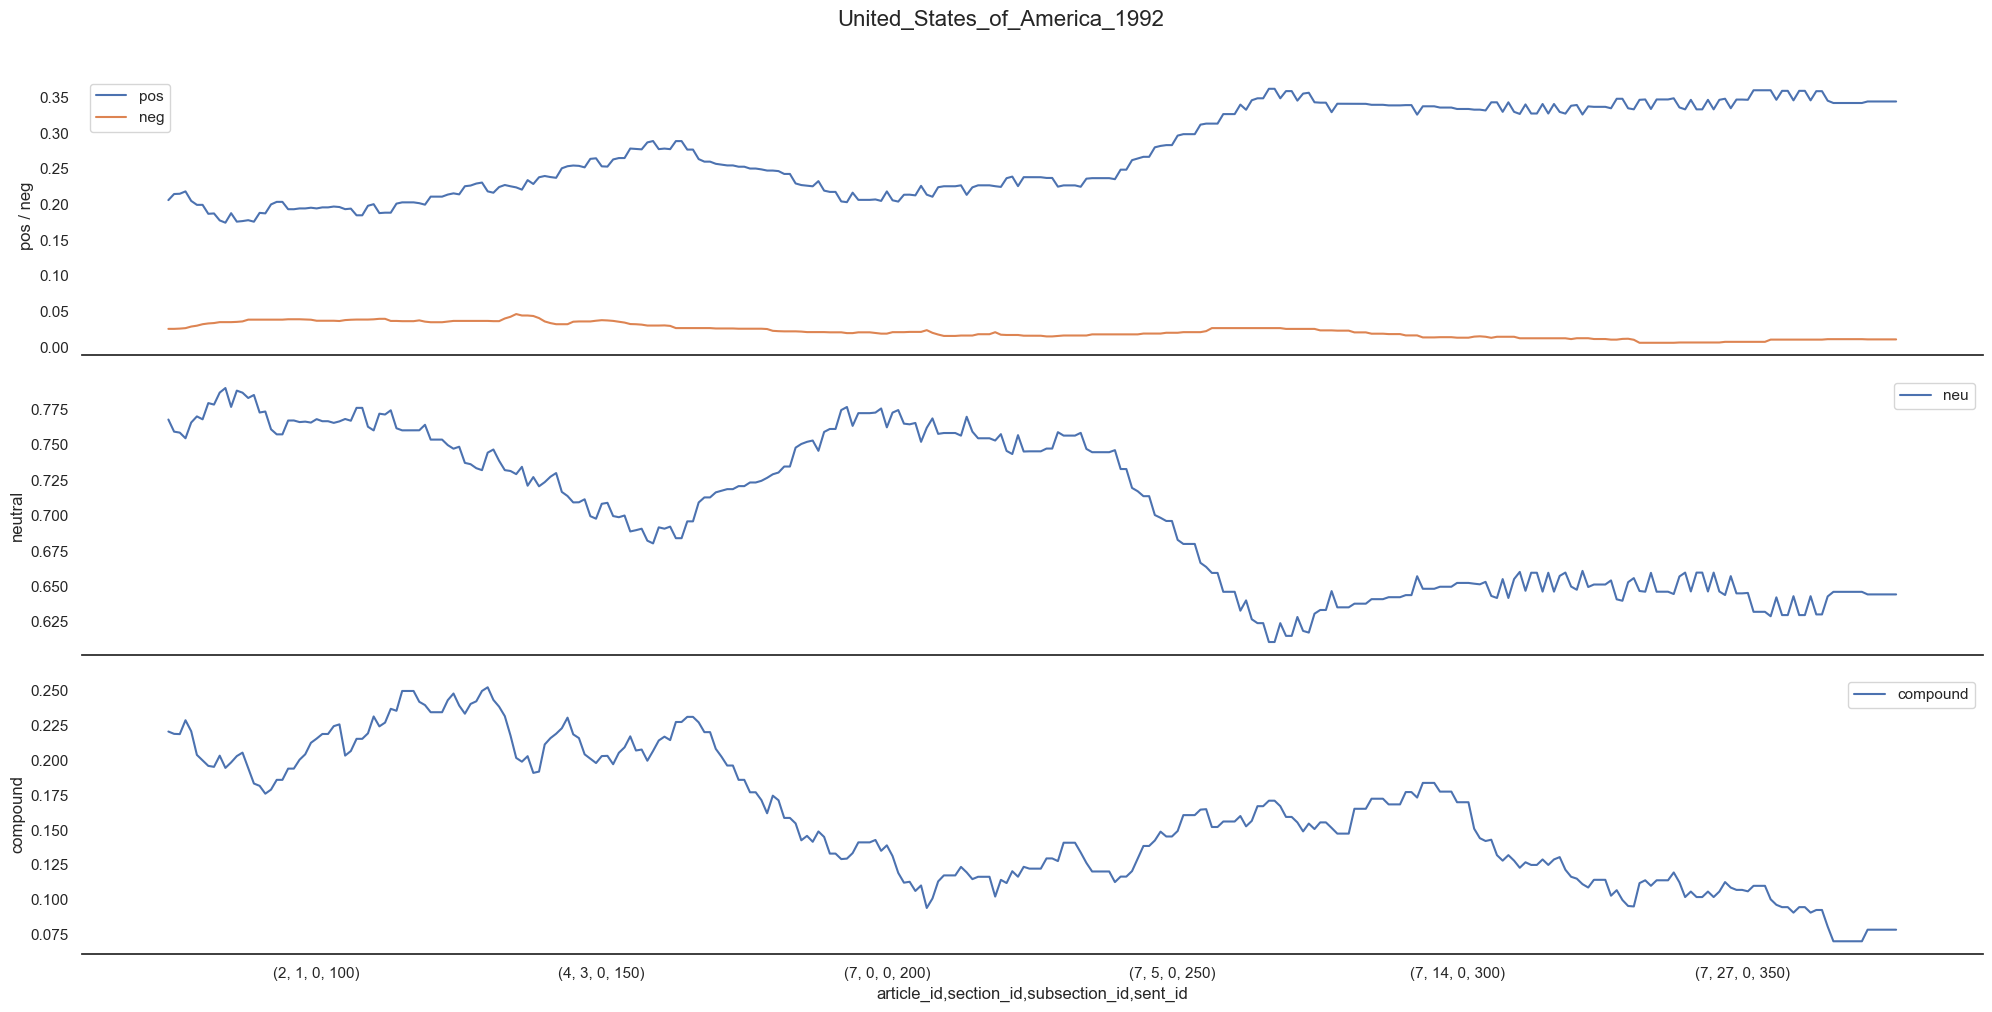

In [20]:
# Replace with valid country_ids from your corpus
plot_country_sa('United_States_of_America_1992')

## VADER Country Comparison

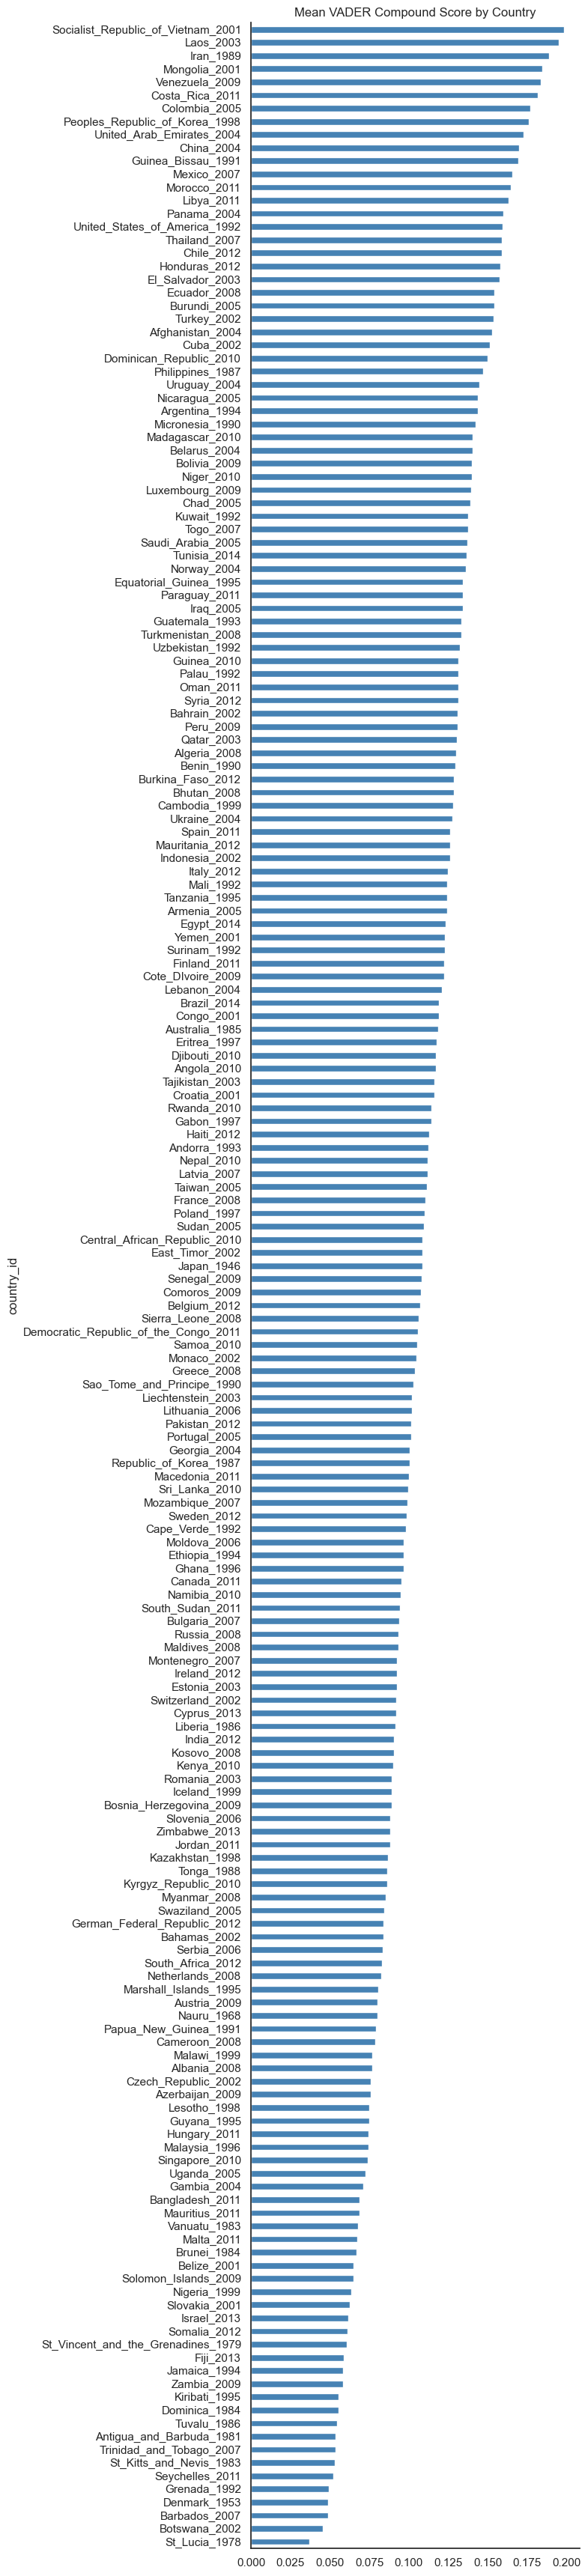

In [21]:
COUNTRY_VADER = SENT_VADER.groupby('country_id').mean()

fig, ax = plt.subplots(figsize=(8, max(6, len(COUNTRY_VADER) * 0.18)))
COUNTRY_VADER['compound'].sort_values().plot.barh(ax=ax, color='steelblue')
ax.axvline(0, c='lightgray', ls='--')
ax.set_title('Mean VADER Compound Score by Country')
sns.despine()
plt.tight_layout()
plt.show()

## Save

In [22]:
SENT_SA.to_csv(f'{output_dir}/const_SENT_SA.csv',       index=True)
SENT_VADER.to_csv(f'{output_dir}/const_SENT_VADER.csv', index=True)
COUNTRY_SA.to_csv(f'{output_dir}/const_COUNTRY_SA.csv', index=True)
print('Saved.')

Saved.
